In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
food=pd.read_csv('food.csv')
menu=pd.read_csv('menu.csv')
order=pd.read_csv('order.csv')
resturant=pd.read_csv('restaurnt.csv')
user=pd.read_csv('users.csv')

In [5]:
resturant=resturant.rename(columns={'name':'Resturant_name'})

In [6]:
user=user.rename(columns={'name':'customer_name'})

In [7]:
resturant=resturant.rename(columns={'id':'r_id'})

In [ ]:
# ============================================================
# FOOD DELIVERY DATA ANALYSIS PROJECT
# ============================================================

# 4. menu টেবিলে সবচেয়ে দামি ১০টি এবং সবচেয়ে সস্তা ১০টি আইটেম বের করুন।
# Find the 10 most expensive and 10 cheapest items from the menu.

# 5. কোন বছরে সবচেয়ে বেশি অর্ডার হয়েছে তা বের করুন।
# বছরভিত্তিক মোট অর্ডার সংখ্যা দেখান।
# Find the year with the highest number of orders and show yearly order counts.

# 6. কোন cuisine সবচেয়ে বেশি রেস্তোরাঁতে পাওয়া যায় তা বের করুন।
# শীর্ষ ১৫টি cuisine প্রদর্শন করুন।
# Find the most common cuisine types across restaurants and show the top 15.

# 7. sales_amount অনুযায়ী সর্বাধিক বিক্রয় করা শীর্ষ ১০টি রেস্তোরাঁ বের করুন।
# Order এবং Restaurant টেবিল merge করে মোট বিক্রয় হিসাব করুন।
# Find the top 10 restaurants by total sales amount.

# 8. occupation অনুযায়ী মোট অর্ডার সংখ্যা বের করুন।
# কোন পেশার ব্যবহারকারীরা সবচেয়ে বেশি অর্ডার করে তা নির্ণয় করুন।
# Analyze order counts by occupation and identify the highest-ordering profession.

# 9. monthly income অনুযায়ী গড় sales_amount বিশ্লেষণ করুন।
# আয়ের স্তরের সাথে অর্ডার পরিমাণের পরিবর্তন পর্যবেক্ষণ করুন।
# Analyze how average order amount varies across monthly income brackets.

# 10. মাসভিত্তিক মোট বিক্রয়ের ট্রেন্ড বিশ্লেষণ করুন।
# order_date থেকে month বের করে sales trend দেখান।
# Analyze month-wise total sales trends over time.

# 11. Restaurant rating এবং মোট order count এর মধ্যে correlation নির্ণয় করুন।
# Determine the relationship between restaurant ratings and number of orders received.

# 12. Cuisine অনুযায়ী menu item-এর গড় মূল্য বের করুন।
# কোন cuisine-এর average price সবচেয়ে বেশি তা নির্ধারণ করুন।
# Find the cuisine with the highest average menu price.

# 13. family_size অনুযায়ী average order amount বিশ্লেষণ করুন।
# পরিবারের আকার অর্ডারের পরিমাণে প্রভাব ফেলে কিনা তা দেখুন।
# Analyze whether family size affects average order value.

# 14. রেস্তোরাঁ সংখ্যা অনুযায়ী শীর্ষ ৫টি শহর নির্বাচন করুন।
# প্রতিটি শহরের average cost এবং average rating তুলনা করুন।
# Compare average restaurant cost and rating for the top 5 cities.

# ---------------------- HARD LEVEL --------------------------

# 15. প্রতিটি রেস্তোরাঁর Veg ও Non-Veg item ratio নির্ণয় করুন।
# সবচেয়ে Veg-friendly restaurants সনাক্ত করুন।
# Calculate Veg vs Non-Veg ratios and identify the most Veg-friendly restaurants.

# 16. RFM Analysis করুন।
# Recency = শেষ অর্ডারের সময়
# Frequency = মোট অর্ডার সংখ্যা
# Monetary = মোট খরচ
# Perform RFM analysis for customer segmentation.

# 17. Education, Marital Status এবং Income ভিত্তিক user segments বিশ্লেষণ করুন।
# Pivot Table ব্যবহার করে সবচেয়ে বেশি spending করা segment বের করুন।
# Build a multi-level pivot table to identify the highest-spending user segment.

# 18. সময়ের সাথে restaurant sales বৃদ্ধি পাচ্ছে নাকি কমছে তা বিশ্লেষণ করুন।
# Restaurant-wise growth rate নির্ণয় করুন।
# Identify restaurants with growing and declining sales trends.

# 19. Market Basket Analysis করুন।
# একই restaurant-এ সবচেয়ে বেশি একসাথে থাকা cuisine pairs বের করুন।
# Build a cuisine co-occurrence matrix and find the most frequent cuisine pairs.

# 20. সব ৫টি টেবিল merge করে একটি comprehensive dashboard summary তৈরি করুন।
# City-wise best restaurants
# Most popular cuisines
# Top user segments by spending
# Build a complete business dashboard using all datasets.
# ============================================================


## Count total Veg vs Non-Veg food items in the dataset.

In [ ]:
food.head(2)

In [13]:
food['veg_or_non_veg'].value_counts().reset_index()

,veg_or_non_veg,count
0,Veg,270776
1,Non-veg,100784



# Which cities have the most restaurants? Show top 10.

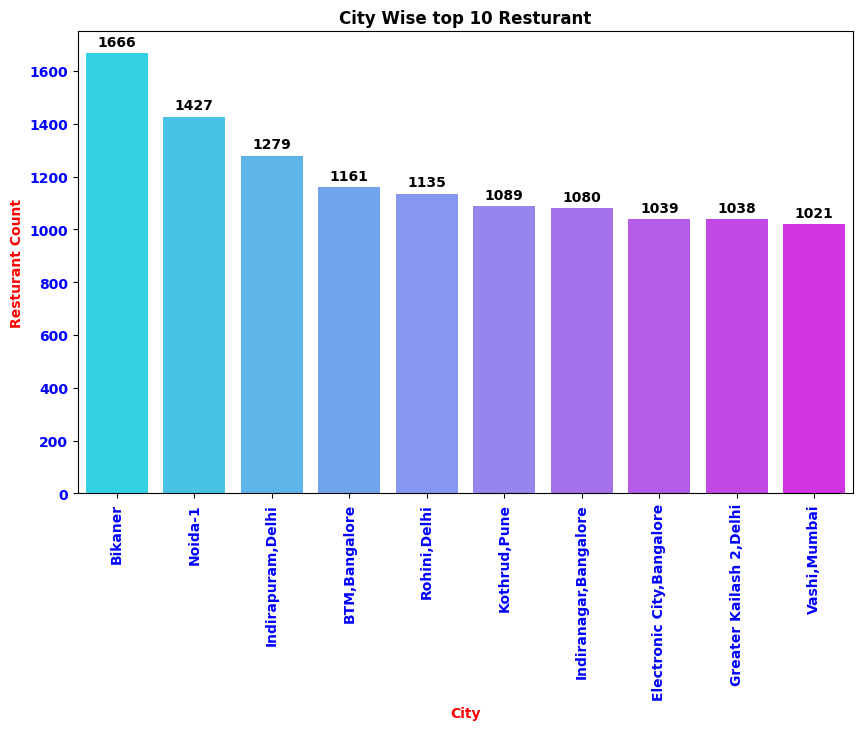

In [48]:
top_rest=resturant.groupby('city')['Resturant_name'].count().sort_values(ascending=False).reset_index().head(10)


plt.figure(figsize=(10,6))
ax=sns.barplot(data=top_rest,x='city',y='Resturant_name',palette='cool')
plt.title('City Wise top 10 Resturant',color='black',fontweight='bold')
plt.xlabel('City', color='red', fontweight='bold')
plt.ylabel('Resturant Count', color='red', fontweight='bold')
plt.xticks(rotation=90, color='blue', fontweight='bold')
plt.yticks(color='blue', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, padding=3,fontweight='bold')


# Find average, max, and min age of users, broken down by gende

In [26]:
customer=(user.groupby('Gender')['Age'].agg(['max','min','mean']).
    round(2).sort_values(by='mean',ascending=False).reset_index())

customer

,Gender,max,min,mean
0,Male,33,18,24.79
1,Female,32,19,24.42



# Find the 10 most expensive and 10 cheapest items from the menu.



In [3]:
menu['price']=pd.to_numeric(menu['price'],errors='coerce')

In [46]:
most_expensive=menu.nlargest(10,'price')[['f_id','cuisine','price']].reset_index()
cheapest=menu.nsmallest(10,'price')[['f_id','cuisine','price']].reset_index()
print('most Expensive item price')
print(most_expensive)
print('most cheapest item price')
print(cheapest)

most Expensive item price
    index      f_id               cuisine   price
0  981729  fd620165      Pizzas,Fast Food  9999.0
1  834136  fd320470       Desserts,Bakery  9990.0
2  974753  fd603779        Chinese,Indian  7999.0
3  974754  fd603779  North Indian,Chinese  7999.0
4  974755  fd603779     Beverages,Italian  7999.0
5  974756  fd603779          Combo,Indian  7999.0
6  974757  fd603779  North Indian,Punjabi  7999.0
7  974758  fd603779  North Indian,Punjabi  7999.0
8  974759  fd603779  North Indian,Chinese  7999.0
9  974760  fd603779      Beverages,Pizzas  7999.0
most cheapest item price
    index      f_id               cuisine  price
0   45006     fd241       Snacks,American    0.0
1   45007    fd3430       Snacks,American    0.0
2   45106     fd241      Snacks,Fast Food    0.0
3   45107    fd3430      Snacks,Fast Food    0.0
4   61198     fd397      Snacks,Fast Food    0.0
5   61199  fd531385      Snacks,Fast Food    0.0
6   63920     fd539  North Indian,Punjabi    0.0
7   639


# Find the most common cuisine types across restaurants and show the top 15.



In [46]:
resturant = resturant.dropna(subset=['cuisine'])

resturant.groupby('cuisine')['Resturant_name'].count().sort_values(ascending=False).reset_index().head(15)

,cuisine,Resturant_name
0,"North Indian,Chinese",6471
1,Indian,6414
2,Chinese,5051
3,North Indian,4775
4,"Indian,Chinese",4374
5,South Indian,3303
6,Bakery,3132
7,"Chinese,Indian",2308
8,"Chinese,North Indian",2288
9,"Bakery,Desserts",2233



# Find the top 10 restaurants by total sales amount.

In [44]:
merge=(resturant.merge(order,on='r_id').groupby('Resturant_name')['sales_amount'].
    sum().sort_values(ascending=False).reset_index().head(10))

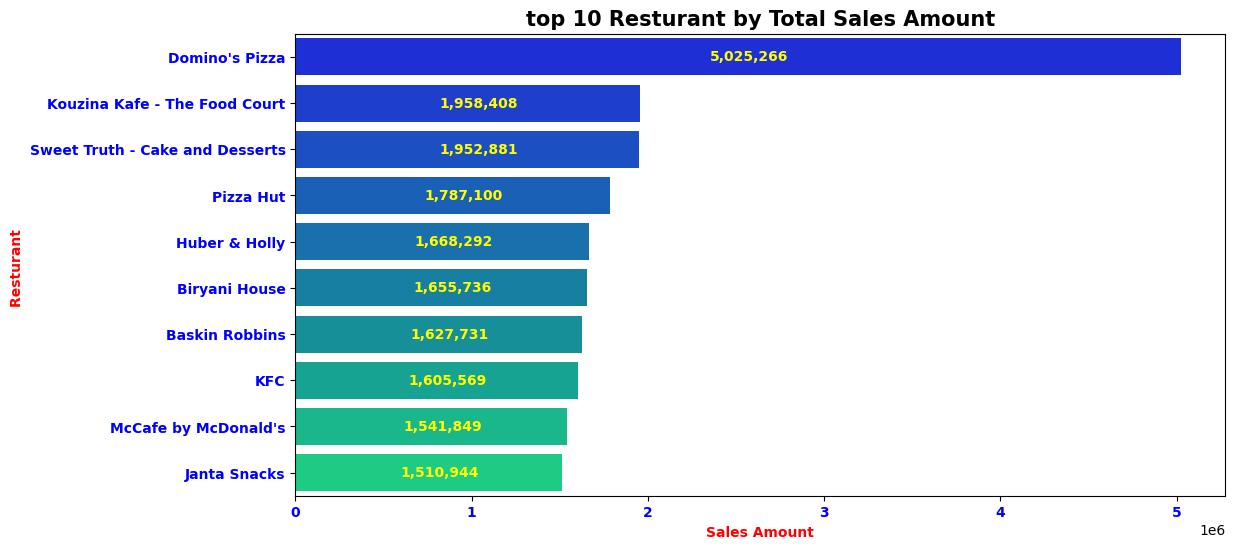

In [45]:
plt.figure(figsize=(12,6))
ax=sns.barplot(data=merge,x='sales_amount',y='Resturant_name',palette='winter')
plt.title('top 10 Resturant by Total Sales Amount',color='black',fontweight='bold',fontsize=15)
plt.xlabel('Sales Amount', color='red', fontweight='bold')
plt.ylabel('Resturant ', color='red', fontweight='bold')
plt.yticks(color='blue', fontweight='bold')
plt.xticks(color='blue', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}',fontweight='bold',label_type='center',color='yellow',padding=8)


In [62]:
merge


,Resturant_name,sales_amount
0,Domino's Pizza,5025266
1,Kouzina Kafe - The Food Court,1958408
2,Sweet Truth - Cake and Desserts,1952881
3,Pizza Hut,1787100
4,Huber & Holly,1668292
5,Biryani House,1655736
6,Baskin Robbins,1627731
7,KFC,1605569
8,McCafe by McDonald's,1541849
9,Janta Snacks,1510944



# Analyze order counts by occupation and identify the highest-ordering profession.



In [37]:
merge=order.merge(user,on='user_id')
merge.head(2)
merge.groupby('Occupation',)['user_id'].size().sort_values(ascending=False).reset_index(name='Total_order')

,Occupation,Total_order
0,Student,80032
1,Employee,45798
2,Self Employeed,20980
3,House wife,3471



# Analyze how average order amount varies across monthly income brackets.



In [51]:
order['order_date']=pd.to_datetime(order['order_date'],dayfirst=True)

In [54]:
order['month']=pd.to_datetime(order['order_date']).dt.month
order.head(2)

,order_date,sales_qty,sales_amount,currency,user_id,r_id,month
0,2017-10-10,100,41241,INR,49226,567335.0,10
1,2018-05-08,3,-1,INR,77359,531342.0,5


In [62]:
order.groupby('month')['sales_amount'].mean().reset_index().rename(columns={'sales_amount':'monthly average sales'})

,month,monthly average sales
0,1,7115.257171
1,2,6530.807088
2,3,6880.199258
3,4,6736.291401
4,5,6155.268772
5,6,5925.770725
6,7,6891.905819
7,8,7568.289229
8,9,6119.146090
9,10,5871.223425



# Analyze month-wise total sales trends .



In [63]:
order.groupby('month')['sales_amount'].sum().reset_index().rename(columns={'sales_amount':'monthly Total sales'})

,month,monthly Total sales
0,1,99713214
1,2,89374095
2,3,92779487
3,4,88838211
4,5,83613171
5,6,75055812
6,7,71420820
7,8,71671699
8,9,55164102
9,10,80805648



# Determine the relationship between restaurant ratings and number of orders received.



In [71]:
order_count=order.groupby('r_id').size().sort_values(ascending=False).reset_index(name='Total_order')
order_count.head(2)

,r_id,Total_order
0,390478.0,2
1,397258.0,2


In [72]:
merge=order_count.merge(resturant,on='r_id')

In [81]:
correlation=merge['rating'].corr(merge['Total_order']).round(4)
print('very poor correlation :',correlation)



very poor correlation : -0.0074


<Axes: >

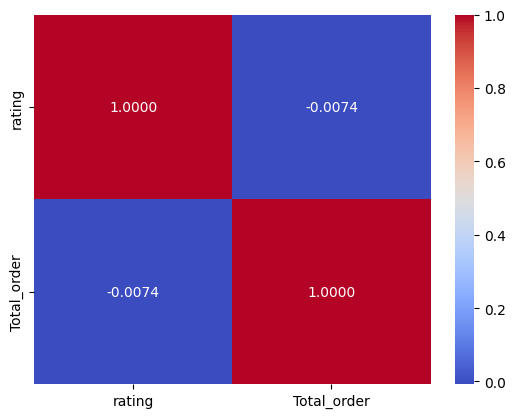

In [87]:
corr_matrix = merge[['rating','Total_order']].corr()
sns.heatmap(corr_matrix,annot=True, cmap='coolwarm',
    fmt='.4f')



# Find the cuisine with the highest average menu price

In [104]:
cuisine_price = (menu.dropna(subset=['cuisine', 'price']))


In [102]:
menu['price'] = menu['price'].str.extract('(\d+)')
menu['price'] = pd.to_numeric(menu['price'])

In [108]:
menu.groupby('cuisine')['price'].mean().sort_values(ascending=False).reset_index(name='avreage price').head()

,cuisine,avreage price
0,"Street Food, Indian, Seafood",1800.0
1,"North Indian, Italian, Asian, Chinese, Thai, C...",1500.0
2,"Indian, Continental, Salads, Snacks",1200.0
3,"Continental, Indian",1200.0
4,"Fast Food, Italian, Snacks, Lebanese",1000.0



# Analyze whether family size affects average order value.




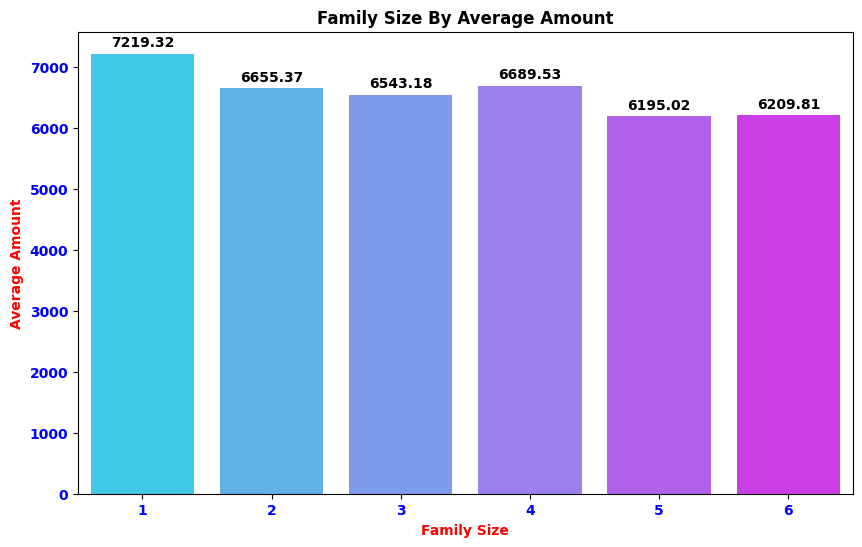

In [25]:
merge=order.merge(user,on='user_id')
group=merge.groupby('Family_size')['sales_amount'].mean().sort_values(ascending=False).reset_index().round(2)

plt.figure(figsize=(10,6))
ax=sns.barplot(data=group,x='Family_size',y='sales_amount',palette='cool')
plt.title('Family Size By Average Amount',color='black',fontweight='bold')
plt.xlabel('Family Size', color='red', fontweight='bold')
plt.ylabel('Average Amount', color='red', fontweight='bold')
plt.xticks(color='blue', fontweight='bold')
plt.yticks(color='blue', fontweight='bold')
for container in ax.containers:
    ax.bar_label(container, padding=3,fontweight='bold')



# Compare average restaurant cost and rating for the top 5 cities.



In [30]:
group=resturant.groupby('city')['Resturant_name'].count().sort_values(ascending=False).reset_index().head(5)



,city,Resturant_name
0,Bikaner,1666
1,Noida-1,1427
2,"Indirapuram,Delhi",1279
3,"BTM,Bangalore",1161
4,"Rohini,Delhi",1135


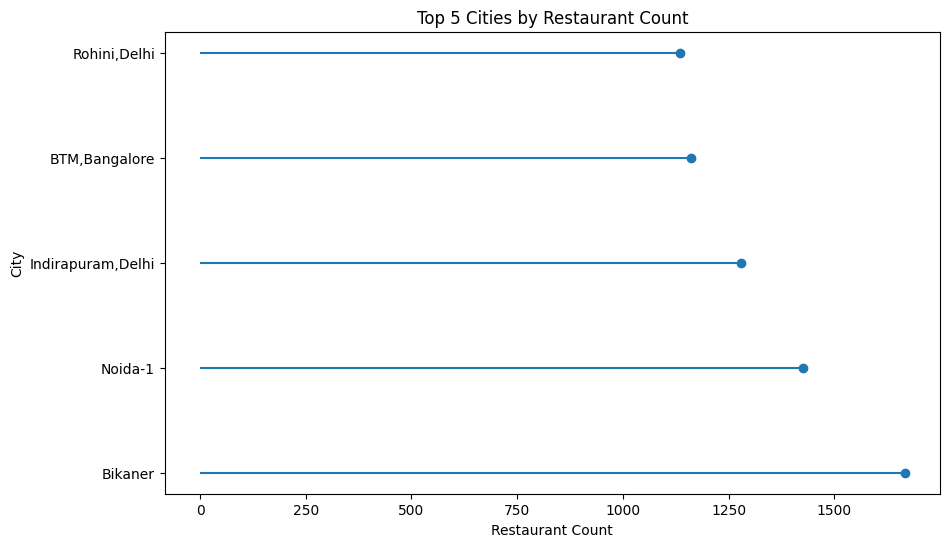

In [37]:
top5 = group.sort_values(
    by='Resturant_name',
    ascending=False
).head(5)

plt.figure(figsize=(10,6))

plt.hlines(
    y=top5['city'],
    xmin=0,
    xmax=top5['Resturant_name']
)

plt.plot(
    top5['Resturant_name'],
    top5['city'],
    "o"
)

plt.title('Top 5 Cities by Restaurant Count')
plt.xlabel('Restaurant Count')
plt.ylabel('City')
plt.show()


# Perform RFM analysis for customer segmentation.

In [29]:
rfm = order.groupby('user_id').agg(
    Last_Order_Date=('order_date', 'max'),
    Frequency=('order_date', 'count'),
    Monetary=('sales_amount', 'sum')
).reset_index()
rfm

,user_id,Last_Order_Date,Frequency,Monetary
0,1,14/11/2018,2,1672
1,2,20/02/2018,3,4061
2,3,15/05/2019,1,21542
3,4,06/02/2019,1,102
4,5,25/07/2018,2,52047
...,...,...,...,...
77924,99995,18/07/2019,2,1454
77925,99996,11/06/2020,2,1898
77926,99997,27/08/2019,4,7908
77927,99998,24/04/2019,2,10921



# Build a multi-level pivot table to identify the highest-spending user segment.


In [41]:
group=order.merge(user,on='user_id')

pd.pivot_table(
    group,
    values='sales_amount',
    index='Educational_Qualifications',
    columns='Marital _tatus',
    aggfunc='mean'
).round(2).reset_index()

Marital _tatus,Educational_Qualifications,Married,Prefer not to say,Single
0,Graduate,6365.76,7440.42,6515.31
1,Ph.D,6435.06,7714.30,6554.88
2,Post Graduate,6483.12,8116.68,6596.72
3,School,6890.14,NaN,6003.39
4,Uneducated,6274.12,NaN,NaN



# Identify restaurants with growing and declining sales trends.



In [63]:
merge=order.merge(resturant,on='r_id')
merge.head(1)
sales_trand=merge.groupby(['Resturant_name','order_date'])['sales_amount'].sum().reset_index()

sales_trand=sales_trand.sort_values(['Resturant_name','order_date'])
sales_trand

sales_trand['growth']=sales_trand.groupby('Resturant_name')['sales_amount'].pct_change()*100
sales_trand['trand']=sales_trand['growth'].apply(lambda x: 'growth' if x>0
                                                 else('declining' if x<0 else 'No Change'))
sales_trand

,Resturant_name,order_date,sales_amount,growth,trand
0,!PUNJ,09/08/2018,7269,NaN,No Change
1,""" KAMAT (Original)- Siripuram""",02/01/2018,1546,NaN,No Change
2,"""C/o. Bhojbari""",06/03/2020,25523,NaN,No Change
3,"""JUICE BAR "" Plan B",19/09/2019,16569,NaN,No Change
4,"""KLV"" Kadal Meen Virpanai Nilayam",06/10/2017,287,NaN,No Change
...,...,...,...,...,...
147453,zwarma,21/12/2017,870,-79.572670,declining
147454,zwarma,27/08/2018,120,-86.206897,declining
147455,zwarma (The Taste of paradise),26/03/2019,2968,NaN,No Change
147456,zwarma - Ulsoor,06/06/2018,199,NaN,No Change



# City-wise best restaurants
# Most popular cuisines
# Top user segments by spending
# Build a complete business dashboard using all datasets

In [8]:
all_merge=(food.merge(menu,on='f_id').merge(resturant,on='r_id').
    merge(order,on='r_id').merge(user,on='user_id'))

In [9]:
all_merge.columns

Index(['f_id', 'item', 'veg_or_non_veg', 'menu_id', 'r_id', 'cuisine_x',
       'price', 'Resturant_name', 'city', 'rating', 'rating_count', 'cost',
       'cuisine_y', 'pincode', 'area', 'order_date', 'sales_qty',
       'sales_amount', 'currency', 'user_id', 'customer_name', 'Age', 'Gender',
       'Marital _tatus', 'Occupation', 'Monthly_Income',
       'Educational_Qualifications', 'Family_size'],
      dtype='object')

In [15]:
(all_merge.groupby(['Resturant_name','city'])['sales_amount'].sum().sort_values(ascending=False).
    reset_index().rename(columns={'sales_amount':'Total_sales'}).head())

,Resturant_name,city,Total_sales
0,Honest,"Navrangpura,Ahmedabad",219573540
1,Krishna Food,"Ghatlodia,Ahmedabad",215691000
2,Huber & Holly,"Navrangpura,Ahmedabad",191297375
3,Mirch Masala,"Ghatlodia,Ahmedabad",182940344
4,Jayhind Sweets,"Ghatlodia,Ahmedabad",168802620


In [18]:
(all_merge.groupby('cuisine_y')['sales_amount'].sum().sort_values(ascending=False).
    reset_index().rename(columns={'cuisine_y':'Most popular cuisines','sales_amount':'Total_sales'}).head())

,Most popular cuisines,Total_sales
0,"Indian,Chinese",695732211
1,"North Indian,Chinese",691066600
2,Indian,636430650
3,North Indian,566580886
4,"North Indian,Punjabi",502736392


In [19]:
(all_merge.groupby('customer_name')['sales_amount'].sum().sort_values(ascending=False).
    reset_index().rename(columns={'sales_amount':'Total_sales'}).head())

,customer_name,Total_sales
0,Dana Gonzalez,219573540
1,Brian White,217615965
2,Cassandra Benson,191297375
3,Kristina Powers,182940344
4,Brittany Mcfarland,168802620
